In [38]:
from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
print("GPU available:", tf.config.list_physical_devices('GPU'))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [39]:
import pandas as pd
import os

APTOS_PATH = '/content/drive/MyDrive/DR_Project/data/aptos'
df_aptos = pd.read_csv(f'{APTOS_PATH}/train.csv')

print("APTOS labels loaded:", df_aptos.shape)
print("\nClass distribution:")
print(df_aptos['diagnosis'].value_counts().sort_index())
df_aptos.head()

APTOS labels loaded: (3662, 2)

Class distribution:
diagnosis
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64


,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0


In [40]:
import os

IMAGES_PATH = f'{APTOS_PATH}/train_images'
image_files = os.listdir(IMAGES_PATH)
print("Number of image files found:", len(image_files))
print("Example filenames:", image_files[:5])

Number of image files found: 3662
Example filenames: ['624fb7317106.png', 'b6bfe9db60e5.png', '07a2b8cabf6b.png', '18323d8f2470.png', '0ad7f631dedb.png']


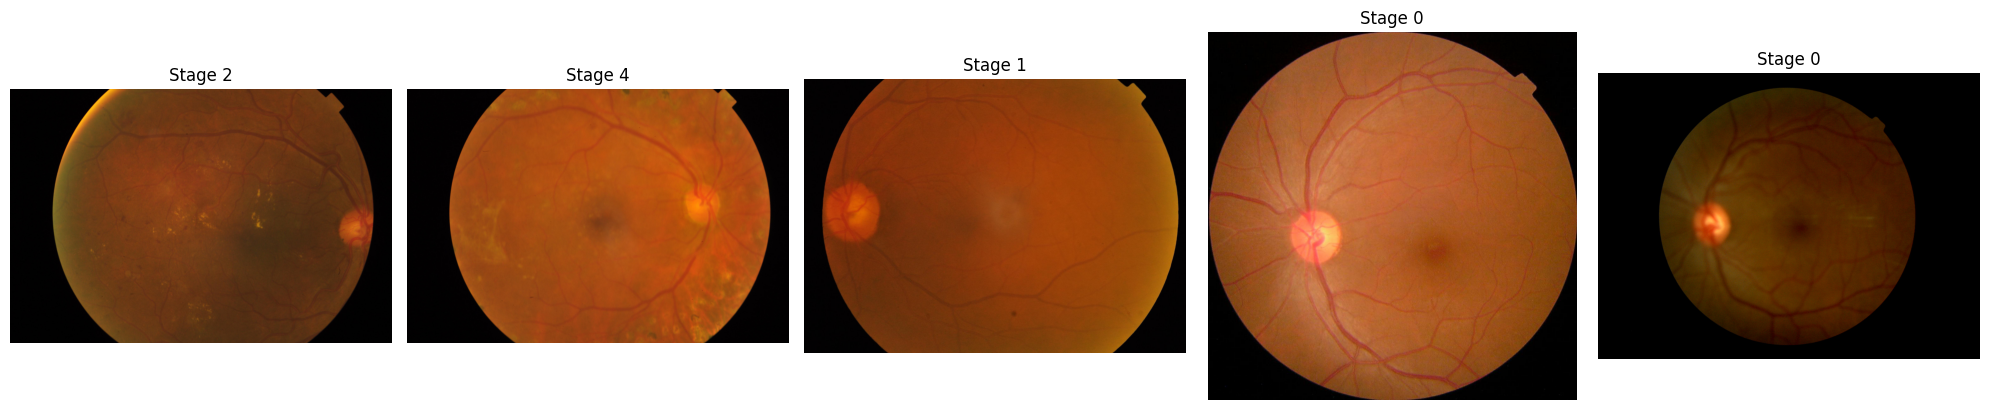

In [41]:
import matplotlib.pyplot as plt
import cv2

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
sample_ids = df_aptos['id_code'].head(5).values
sample_labels = df_aptos['diagnosis'].head(5).values

for i, (img_id, label) in enumerate(zip(sample_ids, sample_labels)):
    img_path = f'{IMAGES_PATH}/{img_id}.png'
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[i].imshow(img)
    axes[i].set_title(f'Stage {label}')
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('/content/sample_aptos_images.png', dpi=100)
plt.show()

In [42]:
sizes = []
for img_id in df_aptos['id_code'].head(20).values:
    img_path = f'{IMAGES_PATH}/{img_id}.png'
    img = cv2.imread(img_path)
    sizes.append(img.shape)

for s in sizes:
    print(s)

(2136, 3216, 3)
(2136, 3216, 3)
(1736, 2416, 3)
(1050, 1050, 3)
(1536, 2048, 3)
(2588, 3388, 3)
(1958, 2588, 3)
(2136, 3216, 3)
(1958, 2588, 3)
(1736, 2416, 3)
(1050, 1050, 3)
(1736, 2416, 3)
(1050, 1050, 3)
(1736, 2416, 3)
(2136, 3216, 3)
(1050, 1050, 3)
(2136, 3216, 3)
(614, 819, 3)
(1536, 2048, 3)
(1000, 1504, 3)


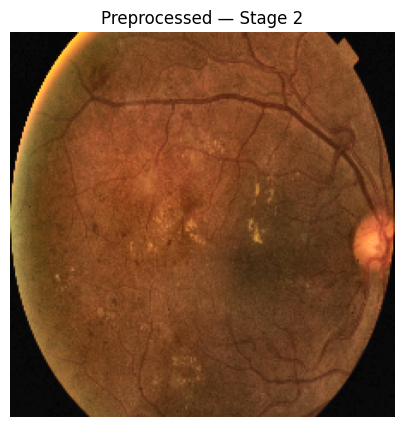

Preprocessed shape: (224, 224, 3)


In [43]:
def preprocess_retinal_image(img_path, target_size=224):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Crop out black padding — find the retina's bounding circle
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    _, thresh = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest_contour)
        img = img[y:y+h, x:x+w]

    # Resize to consistent size
    img = cv2.resize(img, (target_size, target_size))

    # Apply CLAHE to the green channel (best contrast for retinal vessels/lesions)
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    l_clahe = clahe.apply(l)
    lab_clahe = cv2.merge((l_clahe, a, b))
    img_clahe = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2RGB)

    return img_clahe

# Test on one image
test_img = preprocess_retinal_image(f'{IMAGES_PATH}/{sample_ids[0]}.png')
plt.figure(figsize=(5,5))
plt.imshow(test_img)
plt.title(f'Preprocessed — Stage {sample_labels[0]}')
plt.axis('off')
plt.savefig('/content/preprocessed_sample.png', dpi=100)
plt.show()
print("Preprocessed shape:", test_img.shape)

In [44]:
from tqdm import tqdm
import numpy as np

def preprocess_retinal_image(img_path, target_size=224):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    _, thresh = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest_contour)
        img = img[y:y+h, x:x+w]

    img = cv2.resize(img, (target_size, target_size))

    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    l_clahe = clahe.apply(l)
    lab_clahe = cv2.merge((l_clahe, a, b))
    img_clahe = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2RGB)

    return img_clahe

# Process all images
X_images = []
y_labels = []

for idx, row in tqdm(df_aptos.iterrows(), total=len(df_aptos)):
    img_path = f'{IMAGES_PATH}/{row["id_code"]}.png'
    try:
        img = preprocess_retinal_image(img_path)
        X_images.append(img)
        y_labels.append(row['diagnosis'])
    except Exception as e:
        print(f"Failed on {row['id_code']}: {e}")

X_images = np.array(X_images, dtype=np.float32) / 255.0  # normalise to 0-1
y_labels = np.array(y_labels)

print("Final image array shape:", X_images.shape)
print("Final labels shape:", y_labels.shape)

100%|██████████| 3662/3662 [07:09<00:00,  8.52it/s]


Final image array shape: (3662, 224, 224, 3)
Final labels shape: (3662,)


In [45]:
np.save('/content/drive/MyDrive/DR_Project/data/aptos/X_images_preprocessed.npy', X_images)
np.save('/content/drive/MyDrive/DR_Project/data/aptos/y_labels.npy', y_labels)

print("Preprocessed images saved to Drive.")
print("You can now load these directly in future sessions without reprocessing.")

Preprocessed images saved to Drive.
You can now load these directly in future sessions without reprocessing.


In [46]:
from sklearn.model_selection import train_test_split

# First split: 70% train, 30% temp (which becomes val+test)
X_train_img, X_temp_img, y_train_img, y_temp_img = train_test_split(
    X_images, y_labels, test_size=0.30, random_state=42, stratify=y_labels
)

# Second split: split the 30% temp into 15% val, 15% test
X_val_img, X_test_img, y_val_img, y_test_img = train_test_split(
    X_temp_img, y_temp_img, test_size=0.50, random_state=42, stratify=y_temp_img
)

print("Train:", X_train_img.shape, y_train_img.shape)
print("Validation:", X_val_img.shape, y_val_img.shape)
print("Test:", X_test_img.shape, y_test_img.shape)

print("\nTrain class distribution:")
print(pd.Series(y_train_img).value_counts().sort_index())
print("\nValidation class distribution:")
print(pd.Series(y_val_img).value_counts().sort_index())
print("\nTest class distribution:")
print(pd.Series(y_test_img).value_counts().sort_index())

Train: (2563, 224, 224, 3) (2563,)
Validation: (549, 224, 224, 3) (549,)
Test: (550, 224, 224, 3) (550,)

Train class distribution:
0    1263
1     259
2     699
3     135
4     207
Name: count, dtype: int64

Validation class distribution:
0    271
1     55
2    150
3     29
4     44
Name: count, dtype: int64

Test class distribution:
0    271
1     56
2    150
3     29
4     44
Name: count, dtype: int64


In [47]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

# Convert labels to one-hot encoding for multi-class classification
y_train_cat = to_categorical(y_train_img, num_classes=5)
y_val_cat = to_categorical(y_val_img, num_classes=5)
y_test_cat = to_categorical(y_test_img, num_classes=5)

# Load MobileNetV2 pretrained on ImageNet, without the top classification layer
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# Phase 1: freeze the base model — we'll only train our new classification head first
base_model.trainable = False

# Add our custom classification head for 5-stage DR severity
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(5, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,619,461 (9.99 MB)

 Trainable params: 361,477 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [48]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

train_datagen.fit(X_train_img)

print("Data augmentation configured.")

Data augmentation configured.
